1\. **Kernel Density Estimate**

Produce a KDE for a given distribution (by hand, not using seaborn!):

* Fill a numpy array, x,  of len(N) (with N=O(100)) with a variable normally distributed, with a given mean a standard deviation
* Fill an histogram in pyplot taking properly care about the aesthetic
   * use a meaningful number of bins
   * set a proper y axis label
   * set proper value of y axis major ticks labels (e.g. you want to display only integer labels)
   * display the histograms as data points with errors (the error being the poisson uncertainty)
* for every element of x, create a gaussian with the mean corresponding the element value and std as a parameter that can be tuned. The std default value should be:
$$ 1.06 * x.std() * x.size ^{-\frac{1}{5.}} $$
you can use the scipy function `stats.norm()` for that.
* In a separate plot (to be placed beside the original histogram), plot all the gaussian functions so obtained
* Sum (with np.sum()) all the gaussian functions and normalize the result such that the integral matches the integral of the original histogram. For that you could use the `scipy.integrate.trapz()` method


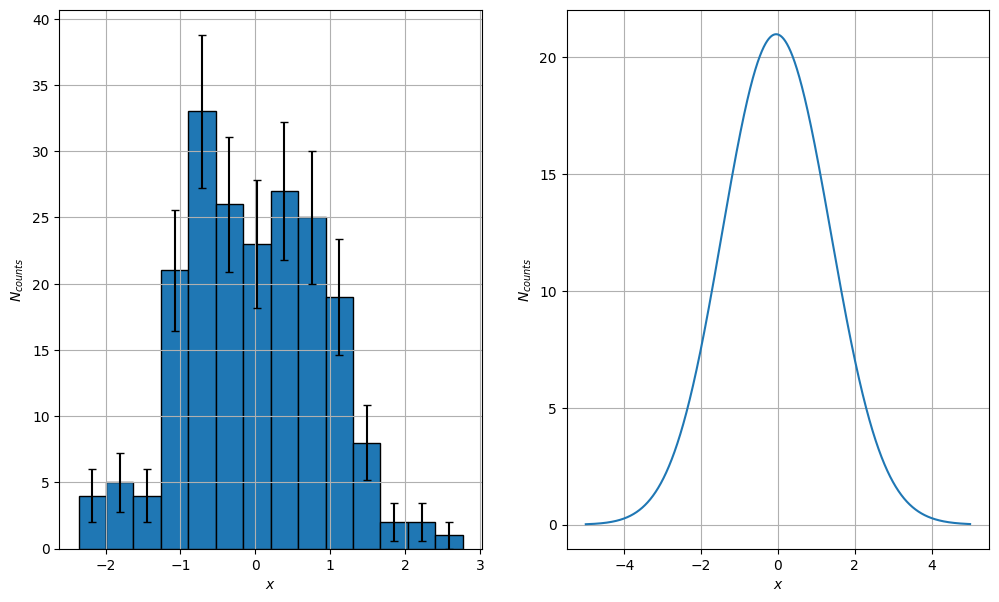

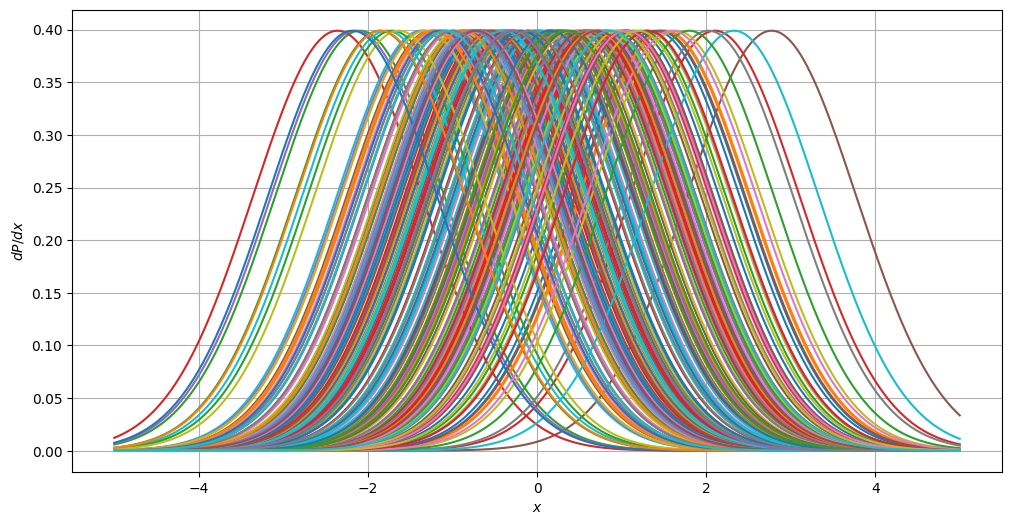

In [1]:
import numpy as np
from matplotlib import pyplot as plt 
from matplotlib.ticker import FuncFormatter
from scipy.stats import norm
from scipy.integrate import trapezoid as trap

mean = 0
std1 = 1
N = 200
X = np.random.normal(mean,std1,N)
#fig, ax = plt.subplots(figsize=(10,6),)

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 7))


def majtick(x,pos):
    if  not x % 1.0:        # Seleziona i multipli di 1
        return "%.0f"% x    # Li printa come numeri con zero cifre decimali

ax1.yaxis.set_major_formatter(FuncFormatter(majtick))

counts,edges = np.histogram(X,int(N**0.5))
bincenters = 0.5*(edges[1:]+edges[0:-1])
ax1.hist(X,int(np.sqrt(N)),edgecolor="black")
ax1.errorbar(bincenters,counts,np.sqrt(counts),fmt="none",ecolor="black",mew=1,capsize=3)
ax1.set_ylabel("$N_{counts}$")
ax1.set_xlabel("$x$")

ax1.grid()

fig2, ax3 = plt.subplots(figsize=(12,6))


std2 = 1
values = np.arange(-1,1,0.0005)*std2*5+np.zeros((N,4000))
gauss = np.array([norm.pdf(values[i],loc=X[i],scale=std2) for i in range(len(values))])
ax3.set_xlabel("$x$")
ax3.set_ylabel("$dP/dx$")
ax3.plot(values.T,gauss.T)
ax3.grid()

allgauss = np.sum(gauss,axis = 0)
cumulative = (allgauss/trap(allgauss,values[0]))*trap(counts,bincenters)
ax2.plot(values[0],cumulative)
ax2.set_ylabel("$N_{counts}$")
ax2.set_xlabel("$x$")
ax2.grid()


2\. **Color-coded scatter plot**

Produce a scatter plot out of a dataset with two categories

* Write a function that generate a 2D datasets of 2 categories. Each category should distribute as a 2D gaussian with a given mean and std (clearly it is better to have different values means..)
* Display the dataset in a scatter plot marking the two categories with different marker colors.

An example is given below

You can try to make the procedure more general by allowing a given number $n\ge 2$ of categories

In [7]:
for name,group in results.groupby("Category"):
    print(name)

0.0
1.0


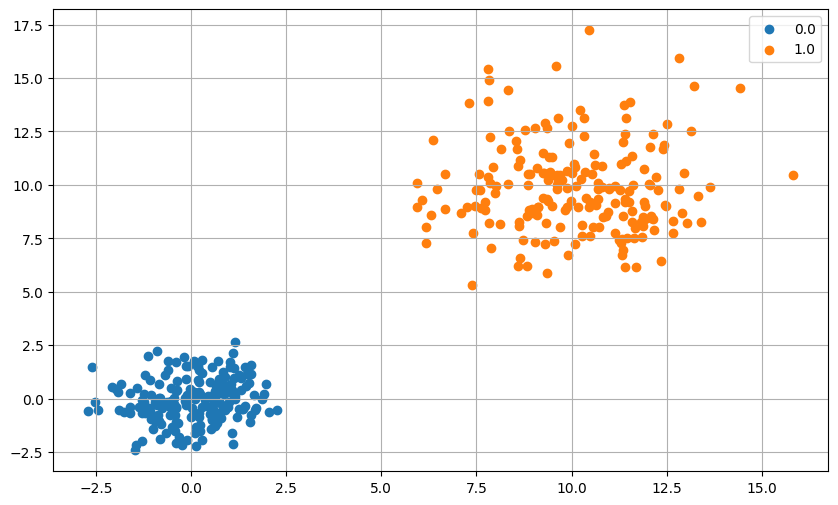

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sample = 200 # Samples of each category
ncat = 2    # number of categories


mean1 = (0,0)
sigma1 = (1,1) 
mean2 = (10,10)
sigma2 = (2,2)

defpars = (mean1, sigma1, mean2, sigma2) # definendo parametri per n dimensioni posso far funzionare ugualmente la funzione




def genfun(pars = defpars):
    sigmas = pars[1::2]
    means = pars[::2]
    res = []
    for idx,sig in enumerate(sigmas):    
        values = np.random.normal(means[idx],sig,(sample,2))
        res.append(values)
    rec = pd.DataFrame(np.array(res).reshape(-1,2),columns=["x","y"])
    rec["Category"] = (np.arange(ncat).reshape(-1,1)*np.ones(sample)).flatten()
    return rec

results = genfun(defpars)

def scatterdf(dataf = results ):
    fig,ax = plt.subplots(figsize=(10, 6))
    for name, group in dataf.groupby("Category"):

        x = group["x"].values
        y = group["y"].values
        ax.scatter(x,y,label=name)
    ax.grid()
    ax.legend()

scatterdf(results)



--2026-01-05 10:32:02--  https://www.dropbox.com/s/u4y3k4kk5tc7j46/two_categories_scatter_plot.png
Resolving www.dropbox.com (www.dropbox.com)... 162.125.69.18, 2620:100:6025:18::a27d:4512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.69.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/70o67xqfkicx6o3pofl37/two_categories_scatter_plot.png?rlkey=b1wnq5kkwhthz0cevmq0mxf35 [following]
--2026-01-05 10:32:04--  https://www.dropbox.com/scl/fi/70o67xqfkicx6o3pofl37/two_categories_scatter_plot.png?rlkey=b1wnq5kkwhthz0cevmq0mxf35
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc08cefad2fcadba8c3448c99471.dl.dropboxusercontent.com/cd/0/inline/C4Z6meBVdPV5-KRc2IOUZ9tvlHgNNq52ia1KNDnA-3mxIzfLlcJUYtJkpi9IB0KaflTJyMlOTWABJHt-EM_J-BM_3MaEHiYvgvYKVrTgdsyUbavXhGJGR1qVwlaizijr3mo/file# [following]
--2026-01-05 10:32:04--  https://uc08cefad2fcadba8c3448c99471.

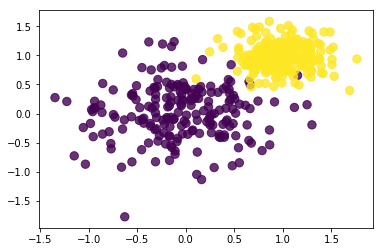

In [19]:
! wget https://www.dropbox.com/s/u4y3k4kk5tc7j46/two_categories_scatter_plot.png
from IPython.display import Image
Image('two_categories_scatter_plot.png')

3\. **Profile plot**

Produce a profile plot from a scatter plot.
* Download the following dataset and load it as a pandas dataframe:
```bash
wget https://www.dropbox.com/s/hgnvyj9abatk8g6/residuals_261.npy
```
Note that you should use the `np.load()` function to load the file as a numpy array, call the `.item()` method, and then pass it to the `pd.DataFrame()` constructor.
* Inspect the dataset, you'll find two variables (features)
* Clean the sample by selecting the entries (rows) with the variable "residual" in absolute value smaller than 2
* perform a linear regression of "residuals" versus "distances" using `scipy.stats.linregress()` 
* plot a seaborn jointplot of  "residuals" versus "distances", having seaborn performing a linear regression. The result of the regression should be displayed on the plot
* Fill 3 numpy arrays
  * x, serving as an array of bin centers for the "distance" variable. It should range from 0 to 20 with reasonable number of steps (bins)
  * y, the mean values of the "residuals", estimated in slices (bins) of "distance"
  * erry, the standard deviation of the  of the "residuals", estimated in slices (bins) of "distance"
* Plot the profile plot on top of the scatter plot

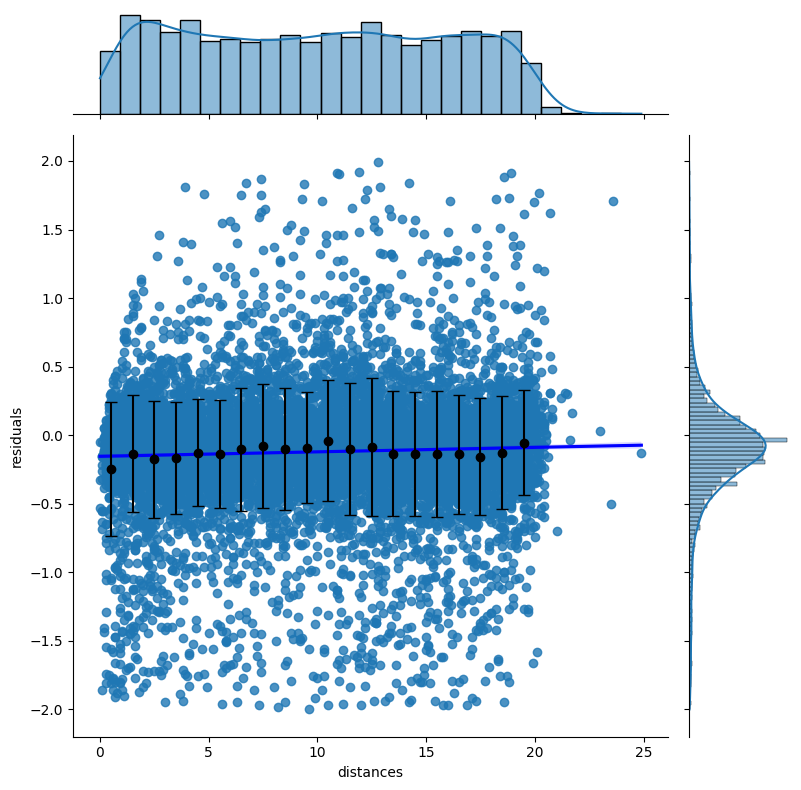

In [16]:
import numpy as np
import pandas as pd
import scipy.stats as st
import seaborn as sns
import matplotlib.pyplot as plt


database = np.load("residuals_261.npy",allow_pickle=True)
dati = pd.DataFrame(database.item())
dataf = dati[dati["residuals"].abs() < 2]

results = st.linregress(dataf["residuals"],dataf["distances"])
#print(results)
g = sns.jointplot(
    x="distances", 
    y="residuals", 
    data=dataf, 
    kind="reg", 
    height=8,
    joint_kws={'line_kws':{'color':'blue'}} # Colore della linea di regressione
)

nbin = 20
binedges = np.linspace(0,20,nbin+1)

x = (binedges[:-1]+binedges[1:])/2 #bincenters
y = np.array([dataf[(dataf["distances"]>=binedges[i])&(dataf["distances"]<binedges[i+1])]["residuals"].mean() for i in range(len(binedges)-1) ])
erry = np.array([dataf[(dataf["distances"]>=binedges[i])&(dataf["distances"]<binedges[i+1])]["residuals"].std() for i in range(len(binedges)-1) ])

g.ax_joint.errorbar(
    x,
    y,
    yerr=erry, 
    fmt='o',      
    color='k',     
    ecolor='black', 
    capsize=4, 
    #label=r'Profile Plot (Mean $\pm$ Std Dev)',
    zorder=10      
)
plt.show()